# Tree Leaf Identification using YOLOv8

This notebook demonstrates how to train a custom **YOLOv8** model to identify leaves from 4 different tree species:
1. **Oak** (forest green, lobed shape)
2. **Maple** (reddish-orange, star-like palmately-lobed shape)
3. **Ginkgo** (golden yellow, fan-like shape)
4. **Pine** (dark green, needle clusters)

Since leaf-specific datasets are often large and difficult to download programmatically, we will first **generate a synthetic dataset** of leaf images with random rotations, translations, and textured backgrounds. We will automatically output the bounding boxes in YOLO format, train the model, and then visualize the predictions.

## 1. Import Dependencies

In [1]:
import os
import random
import shutil
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)

## 2. Programmatic Leaf Generation & Dataset Preparation

We define helper functions to draw the 4 different leaf types on a transparent canvas, apply random transformations (scale, rotate, translate), composite them onto textured backgrounds, and save the corresponding labels.

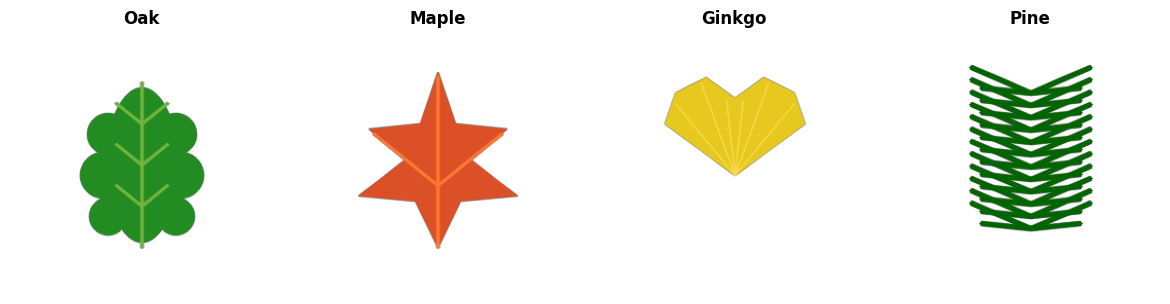

In [2]:
def create_oak_leaf():
    # Oak leaf is green and lobed
    img = np.zeros((256, 256, 4), dtype=np.uint8)
    # Draw stem
    cv2.line(img, (128, 220), (128, 40), (42, 60), 6, lineType=cv2.LINE_AA) # brown stem
    # Draw lobes using overlapping green circles/ellipses
    color = (34, 139, 34, 255) # Forest green
    cv2.ellipse(img, (128, 130), (35, 75), 0, 0, 360, color, -1, lineType=cv2.LINE_AA)
    # Add lobes
    cv2.circle(img, (95, 100), 20, color, -1, lineType=cv2.LINE_AA)
    cv2.circle(img, (161, 100), 20, color, -1, lineType=cv2.LINE_AA)
    cv2.circle(img, (90, 140), 22, color, -1, lineType=cv2.LINE_AA)
    cv2.circle(img, (166, 140), 22, color, -1, lineType=cv2.LINE_AA)
    cv2.circle(img, (95, 180), 18, color, -1, lineType=cv2.LINE_AA)
    cv2.circle(img, (161, 180), 18, color, -1, lineType=cv2.LINE_AA)
    # Overlay leaf veins (lighter green)
    vein_color = (60, 179, 113, 255)
    cv2.line(img, (128, 210), (128, 50), vein_color, 2, lineType=cv2.LINE_AA)
    for y in [90, 130, 170]:
        cv2.line(img, (128, y), (128 - 25, y - 20), vein_color, 2, lineType=cv2.LINE_AA)
        cv2.line(img, (128, y), (128 + 25, y - 20), vein_color, 2, lineType=cv2.LINE_AA)
    return img

def create_maple_leaf():
    # Maple leaf is reddish-orange and has 5 pointy lobes
    img = np.zeros((256, 256, 4), dtype=np.uint8)
    # Draw stem
    cv2.line(img, (128, 220), (128, 140), (20, 30, 100), 4, lineType=cv2.LINE_AA)
    # Points for a 5-lobed maple shape
    pts = np.array([
        [128, 40], [145, 90], [195, 95], [160, 125],
        [205, 160], [150, 165], [128, 210], [106, 165],
        [51, 160], [96, 125], [61, 95], [111, 90]
    ], dtype=np.int32)
    color = (39, 80, 220, 255) # Red-orange (BGR: 39, 80, 220 = red-orange)
    cv2.fillPoly(img, [pts], color, lineType=cv2.LINE_AA)
    # Draw veins
    vein_color = (50, 120, 255, 255)
    cv2.line(img, (128, 210), (128, 45), vein_color, 2, lineType=cv2.LINE_AA)
    cv2.line(img, (128, 150), (190, 100), vein_color, 2, lineType=cv2.LINE_AA)
    cv2.line(img, (128, 150), (66, 100), vein_color, 2, lineType=cv2.LINE_AA)
    return img

def create_ginkgo_leaf():
    # Ginkgo leaf is fan-shaped and golden yellow
    img = np.zeros((256, 256, 4), dtype=np.uint8)
    # Draw long thin stem
    cv2.line(img, (128, 220), (128, 140), (34, 112, 139), 3, lineType=cv2.LINE_AA)
    # Draw fan shape using filled circle sector or polygon
    color = (30, 200, 230, 255) # Yellow-gold (BGR)
    # We can approximate with a fan polygon
    pts = np.array([
        [128, 140], [60, 90], [70, 60], [100, 45], [128, 65],
        [156, 45], [186, 60], [196, 90]
    ], dtype=np.int32)
    cv2.fillPoly(img, [pts], color, lineType=cv2.LINE_AA)
    # Draw veins spreading from base
    vein_color = (80, 220, 250, 255)
    for end_pt in [[70, 70], [95, 50], [120, 67], [136, 67], [161, 50], [186, 70]]:
        cv2.line(img, (128, 140), end_pt, vein_color, 1, lineType=cv2.LINE_AA)
    return img

def create_pine_leaf():
    # Pine needle clusters (dark green, radial/linear thin lines)
    img = np.zeros((256, 256, 4), dtype=np.uint8)
    color = (0, 100, 0, 255) # Dark green
    # Draw main central stem
    cv2.line(img, (128, 220), (128, 40), (20, 50, 40), 5, lineType=cv2.LINE_AA)
    # Draw needles branching outward
    for y in range(60, 200, 12):
        # Left needles
        cv2.line(img, (128, y), (70, y - 25), color, 3, lineType=cv2.LINE_AA)
        cv2.line(img, (128, y), (80, y - 5), color, 3, lineType=cv2.LINE_AA)
        # Right needles
        cv2.line(img, (128, y), (186, y - 25), color, 3, lineType=cv2.LINE_AA)
        cv2.line(img, (128, y), (176, y - 5), color, 3, lineType=cv2.LINE_AA)
    return img

# Visualize the 4 raw template leaf types
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
titles = ["Oak", "Maple", "Ginkgo", "Pine"]
creators = [create_oak_leaf, create_maple_leaf, create_ginkgo_leaf, create_pine_leaf]

for ax, title, creator in zip(axes, titles, creators):
    leaf_img = creator()
    # Convert BGRA to RGBA for plotting
    ax.imshow(cv2.cvtColor(leaf_img, cv2.COLOR_BGRA2RGBA))
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('off')
plt.tight_layout()
plt.show()

### 2.1 Transformation & Background Compositing
To make the dataset challenging and realistic, we will generate synthetic backgrounds with random textures (soil/bark-like colors and noise), apply random rotation, scaling, and translation to each leaf, paste it, and compute the precise bounding box in YOLO format.

In [3]:
def generate_textured_background(size=256):
    # Create a light beige/soil/grey background with noise
    bg = np.zeros((size, size, 3), dtype=np.uint8)
    # Random base color (brown/grey)
    base_b = random.randint(200, 220)
    base_g = random.randint(210, 225)
    base_r = random.randint(215, 230)
    bg[:, :] = [base_b, base_g, base_r]
    # Add Gaussian/uniform noise
    noise = np.random.randint(-15, 15, (size, size, 3))
    bg = np.clip(bg.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    # Add some soft color blobs/shadows
    for _ in range(3):
        cx, cy = random.randint(0, size), random.randint(0, size)
        r = random.randint(30, 85)
        color = [random.randint(180, 200), random.randint(190, 210), random.randint(195, 215)]
        cv2.circle(bg, (cx, cy), r, color, -1, lineType=cv2.LINE_AA)
    # Smooth it slightly to look natural
    bg = cv2.GaussianBlur(bg, (5, 5), 0)
    return bg

def generate_synthetic_sample(leaf_creator, bg_size=256):
    # Create leaf template
    leaf = leaf_creator()
    
    # Apply random transform (scale, rotate, translate)
    scale = random.uniform(0.5, 0.95)
    angle = random.uniform(0, 360)
    tx = random.randint(-40, 40)
    ty = random.randint(-40, 40)
    
    # Rotation and scale matrix
    M = cv2.getRotationMatrix2D((128, 128), angle, scale)
    # Add translation to matrix
    M[0, 2] += tx
    M[1, 2] += ty
    
    # Warp the leaf template and its mask
    warped_leaf = cv2.warpAffine(leaf, M, (256, 256), flags=cv2.INTER_LINEAR)
    
    # Extract color and mask
    leaf_rgb = warped_leaf[:, :, :3]
    leaf_mask = warped_leaf[:, :, 3]
    
    # Find bounding box of the warped leaf from the mask
    pts = cv2.findNonZero(leaf_mask)
    if pts is None:
        # Fallback if leaf gets completely warped out (rare)
        return generate_synthetic_sample(leaf_creator, bg_size)
    
    x, y, w, h = cv2.boundingRect(pts)
    
    # Load background
    bg = generate_textured_background(bg_size)
    
    # Composite leaf onto background
    mask_inv = cv2.bitwise_not(leaf_mask)
    bg_bg = cv2.bitwise_and(bg, bg, mask=mask_inv)
    leaf_fg = cv2.bitwise_and(leaf_rgb, leaf_rgb, mask=leaf_mask)
    final_img = cv2.add(bg_bg, leaf_fg)
    
    # Convert bounding box to YOLO normalization: cx, cy, w, h
    cx = (x + w / 2.0) / bg_size
    cy = (y + h / 2.0) / bg_size
    nw = w / bg_size
    nh = h / bg_size
    
    return final_img, (cx, cy, nw, nh)

### 2.2 Dataset Structuring
Let's create the folders and generate the synthetic dataset (120 training images and 40 validation images).

In [4]:
dataset_dir = Path('../../data/leaves')
train_img_dir = dataset_dir / 'train/images'
train_lbl_dir = dataset_dir / 'train/labels'
val_img_dir = dataset_dir / 'val/images'
val_lbl_dir = dataset_dir / 'val/labels'

# Clean up existing data directories if they exist
if dataset_dir.exists():
    shutil.rmtree(dataset_dir)

# Create directories
train_img_dir.mkdir(parents=True, exist_ok=True)
train_lbl_dir.mkdir(parents=True, exist_ok=True)
val_img_dir.mkdir(parents=True, exist_ok=True)
val_lbl_dir.mkdir(parents=True, exist_ok=True)

classes = ['Oak', 'Maple', 'Ginkgo', 'Pine']
creators = [create_oak_leaf, create_maple_leaf, create_ginkgo_leaf, create_pine_leaf]

# Generate Train dataset
samples_per_class_train = 30
for class_id, creator in enumerate(creators):
    for i in range(samples_per_class_train):
        img, bbox = generate_synthetic_sample(creator)
        img_name = f"{classes[class_id]}_train_{i}.jpg"
        lbl_name = f"{classes[class_id]}_train_{i}.txt"
        
        cv2.imwrite(str(train_img_dir / img_name), img)
        with open(train_lbl_dir / lbl_name, 'w') as f:
            f.write(f"{class_id} {bbox[0]:.6f} {bbox[1]:.6f} {bbox[2]:.6f} {bbox[3]:.6f}\n")

# Generate Val dataset
samples_per_class_val = 10
for class_id, creator in enumerate(creators):
    for i in range(samples_per_class_val):
        img, bbox = generate_synthetic_sample(creator)
        img_name = f"{classes[class_id]}_val_{i}.jpg"
        lbl_name = f"{classes[class_id]}_val_{i}.txt"
        
        cv2.imwrite(str(val_img_dir / img_name), img)
        with open(val_lbl_dir / lbl_name, 'w') as f:
            f.write(f"{class_id} {bbox[0]:.6f} {bbox[1]:.6f} {bbox[2]:.6f} {bbox[3]:.6f}\n")

print(f"Dataset generated successfully! Location: {dataset_dir.resolve()}")

Dataset generated successfully! Location: C:\Users\xinod\Documents\Projects\CEC616\data\leaves


Let's visualize a few samples from the generated training set with their bounding boxes overlayed to verify correctness.

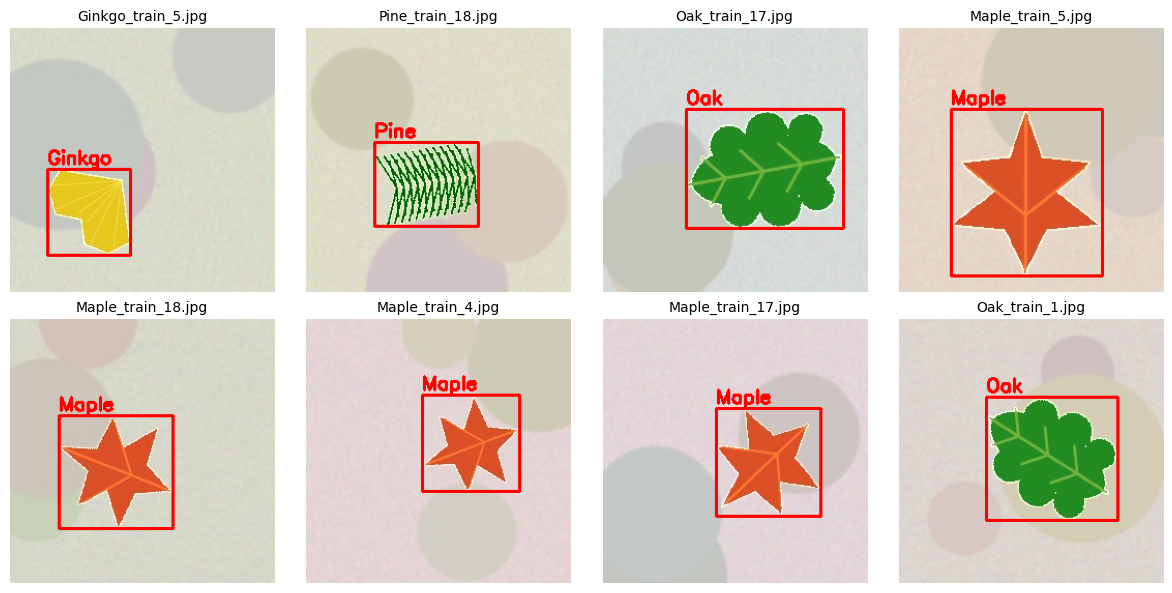

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
train_images = list(train_img_dir.glob('*.jpg'))
random.shuffle(train_images)

for idx, ax in enumerate(axes.flat):
    img_path = train_images[idx]
    lbl_path = train_lbl_dir / f"{img_path.stem}.txt"
    
    img = cv2.imread(str(img_path))
    h_img, w_img, _ = img.shape
    
    with open(lbl_path, 'r') as f:
        lines = f.readlines()
    
    for line in lines:
        cid, cx, cy, w, h = map(float, line.strip().split())
        cid = int(cid)
        
        # Convert normalized center-coordinates to pixel corner-coordinates
        x1 = int((cx - w/2) * w_img)
        y1 = int((cy - h/2) * h_img)
        x2 = int((cx + w/2) * w_img)
        y2 = int((cy + h/2) * h_img)
        
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 2)
        cv2.putText(img, classes[cid], (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)
        
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(img_path.name, fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

### 2.3 Create YAML configuration file for YOLO

In [6]:
yaml_content = f"""
path: {dataset_dir.resolve().as_posix()}
train: train/images
val: val/images

names:
  0: Oak
  1: Maple
  2: Ginkgo
  3: Pine
"""

yaml_path = dataset_dir / 'leaves.yaml'
with open(yaml_path, 'w') as f:
    f.write(yaml_content.strip())

print(f"YAML config created at: {yaml_path.resolve()}")

YAML config created at: C:\Users\xinod\Documents\Projects\CEC616\data\leaves\leaves.yaml


## 3. Train YOLOv8 Model

We load a pre-trained `yolov8n.pt` model and fine-tune it on our synthetic leaf dataset. We run training for 10 epochs. Since the dataset is small and image dimensions are 256x256, training is very fast even on CPU.

In [7]:
# Load a pre-trained YOLOv8 nano model
model = YOLO('yolov8n.pt')

# Fine-tune/train model
results = model.train(
    data=str(yaml_path.resolve().as_posix()),
    epochs=10,
    imgsz=256,
    batch=16,
    workers=0,  # avoid multiprocessing issues on windows notebook
    device='cpu' # train on CPU
)

New https://pypi.org/project/ultralytics/8.4.69 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.50  Python-3.12.10 torch-2.11.0+cpu CPU (Intel Core i7-6600U 2.60GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:/Users/xinod/Documents/Projects/CEC616/data/leaves/leaves.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=256, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937,

## 4. Model Inference and Visualizing Predictions

Let's test the model on newly generated test samples that it hasn't seen during training, and check its predictions.

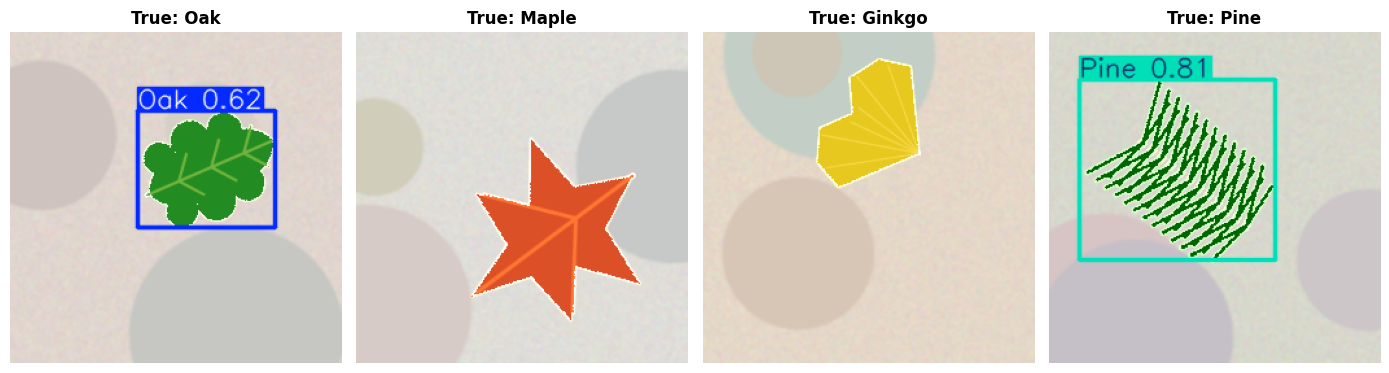

In [8]:
# Generate 4 fresh test samples (one for each class)
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for class_id, creator in enumerate(creators):
    # Generate fresh test image
    test_img, _ = generate_synthetic_sample(creator)
    
    # Predict with trained model
    prediction_results = model(test_img, verbose=False)[0]
    
    # Plot the predicted bounding box on the image
    annotated_img = prediction_results.plot()
    
    axes[class_id].imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
    axes[class_id].set_title(f"True: {classes[class_id]}", fontsize=12, fontweight='bold')
    axes[class_id].axis('off')

plt.tight_layout()
plt.show()